# From Earth to Plate - 03: The model - clustering foods by absolute stage-level emissions signatures

**Maurice Baz & Dominika Bondyra** - JH Data Patterns and Representations, final project.

This notebook is the modeling climax of the deck: an unsupervised look at 43 food products,
each described by the 7 absolute stage-level values (kg CO2e per kg) of its greenhouse-gas
footprint. Clustering by absolute stage-level emissions signatures, a high-impact animal
cluster emerges without using the animal/plant labels - while eggs, milk, and farmed fish
join the lower-emission mixed group. The stage-level view then makes the single most
actionable point of the project: for the highest-impact foods, farm and land-use change
dominate the footprint; transport is small.

**Slide-to-figure mapping**

| Deck slot | Figure file |
|---|---|
| Slide 6 (main) | `figures/fig_slide06_stage_contributions.png` |
| Slide 12 appendix | `figures/fig_appendix_slide06_silhouette.png` |
| Slide 12 appendix | `figures/fig_appendix_slide06_clusters_pca.png` |
| Slide 12 appendix | `figures/fig_appendix_slide06_dendrogram.png` |
| Slide 12 appendix | `figures/fig_appendix_slide06_composition_check.png` |


## Data and basis decision

- **Source:** Poore & Nemecek (2018), *Reducing food's environmental impacts through producers
  and consumers*, Science - global average emissions for 43 food products, as distributed by
  Our World in Data (`data/Food_Product_Emissions.csv`). Units: **kg CO2e per kg of food**.
- **Features:** the 7 stage columns - Land Use Change, Feed, Farm, Processing, Transport,
  Packaging, Retail. They sum (within rounding) to the **"Total from Land to Retail"** column,
  which we call the *land-to-retail total* and use as the emissions basis everywhere in this
  project. Rationale: it is a consistent supply-chain accounting boundary for every food.
  (The source file also provides a "Total Global Average GHG Emissions per kg" column - on
  that basis beef reads 99.5 kg CO2e per kg instead of 59.6. The repository does not document
  the exact scope difference between the two measures, so we quote that column only as a
  companion per-kg series and never mix the two bases.)
- **Negative values:** Land Use Change is *negative* for some crops (Nuts -2.05, Olive Oil
  -0.38, small negatives for Apples, Bananas, Citrus, Potatoes, Rice, Wine). Negative means
  net carbon **sequestration** - e.g. nut orchards standing on former cropland. We keep the
  sign: it is real signal, and we handle it explicitly in the composition check (appendix).
- **Category labels** (used across all four notebooks): 10 **animal-based** products -
  Beef (beef herd), Beef (dairy herd), Cheese, Eggs, Fish (farmed), Lamb & Mutton, Milk,
  Pig Meat, Poultry Meat, Shrimps (farmed) - and 33 **plant-based**. The categories are
  *held out* of the model and used only to validate the clusters afterwards.


In [1]:
# Setup: libraries, robust paths, and the shared house style
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')  # silences the Windows/MKL KMeans warning

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# --- house style (identical across the four project notebooks) ---
SURFACE = '#fcfcfb'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASE = '#e1e0d9', '#c3c2b7'
SLOTS = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834', '#4a3aa7']
BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE, VIOLET = SLOTS
LIGHT_BLUE, EMPH_BLUE = '#9ec5f4', '#104281'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'text.color': INK, 'axes.titlecolor': INK,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': BASE, 'axes.linewidth': 1.0,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'legend.frameon': False,
})

def style_ax(ax, value_axis='y', spines=('bottom',)):
    """Hairline grid on the value axis only, behind the data; no chart box."""
    ax.set_axisbelow(True)
    for a in ('x', 'y'):
        if value_axis in (a, 'both'):
            ax.grid(True, axis=a, color=GRID, linewidth=0.8)
        else:
            ax.grid(False, axis=a)
    for side in ('top', 'right', 'left', 'bottom'):
        ax.spines[side].set_visible(side in spines)
        if side in spines:
            ax.spines[side].set_color(BASE)

def title_block(ax, title, subtitle, pad=32, sub_y=1.02):
    ax.set_title(title, loc='left', fontsize=13, fontweight=600, color=INK, pad=pad)
    ax.text(0, sub_y, subtitle, transform=ax.transAxes, fontsize=9.5, color=INK2, va='bottom')

def source_note(fig, text='Source: Poore & Nemecek (2018), via Our World in Data', y=-0.02):
    fig.text(0.01, y, text, fontsize=8.5, color=MUTED, ha='left')

def ink_on(hexcolor):
    """Label ink inside a colored fill: white or near-black, chosen by fill luminance."""
    r, g, b = (int(hexcolor[i:i + 2], 16) / 255 for i in (1, 3, 5))
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in (r, g, b)]
    lum = 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    return INK if lum > 0.3 else '#ffffff'

def save_fig(fig, name):
    path = FIGS / name
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print('saved', path)


In [2]:
df = pd.read_csv(DATA / 'Food_Product_Emissions.csv')
STAGES = ['Land Use Change', 'Feed', 'Farm', 'Processing', 'Transport', 'Packaging', 'Retail']
TOTAL = 'Total from Land to Retail'
ANIMAL = ['Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Eggs', 'Fish (farmed)',
          'Lamb & Mutton', 'Milk', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)']
df['Category'] = np.where(df['Food product'].isin(ANIMAL), 'Animal-based', 'Plant-based')

# Sanity checks: 43 foods, no missing values, stages reconcile to the land-to-retail total
assert len(df) == 43 and df[STAGES + [TOTAL]].notna().all().all()
assert np.allclose(df[STAGES].sum(axis=1), df[TOTAL], atol=0.02), 'stages must sum to the total'
assert (df['Category'] == 'Animal-based').sum() == 10

ix = df.set_index('Food product')
ratio = ix.loc['Beef (beef herd)', TOTAL] / ix.loc['Peas', TOTAL]
print(f"{len(df)} foods | {df['Category'].value_counts().to_dict()}")
print(f"Land-to-retail totals: Beef (beef herd) {ix.loc['Beef (beef herd)', TOTAL]:.2f}, "
      f"Peas {ix.loc['Peas', TOTAL]:.3f} kg CO2e/kg -> ratio {ratio:.1f}x")
df.head(6)


43 foods | {'Plant-based': 33, 'Animal-based': 10}
Land-to-retail totals: Beef (beef herd) 59.57, Peas 0.896 kg CO2e/kg -> ratio 66.5x


,Food product,Land Use Change,Feed,Farm,Processing,Transport,Packaging,Retail,Total from Land to Retail,Total Global Average GHG Emissions per kg,Unit of GHG Emissions,Category
0,Apples,-0.029,0.000,0.225,0.004,0.096,0.044,0.017,0.357,0.43,kg CO2e per kg food produced,Plant-based
1,Bananas,-0.025,0.000,0.266,0.059,0.292,0.065,0.021,0.678,0.86,kg CO2e per kg food produced,Plant-based
2,Barley,0.009,0.000,0.176,0.128,0.035,0.497,0.264,1.109,1.18,kg CO2e per kg food produced,Plant-based
3,Beef (beef herd),16.278,1.878,39.388,1.269,0.346,0.247,0.164,59.570,99.48,kg CO2e per kg food produced,Animal-based
4,Beef (dairy herd),0.906,2.508,15.689,1.108,0.424,0.268,0.182,21.085,33.30,kg CO2e per kg food produced,Animal-based
5,Beet Sugar,0.000,0.000,0.536,0.242,0.629,0.090,0.039,1.536,1.81,kg CO2e per kg food produced,Plant-based


## Method: standardize, cluster, score, validate

1. **Features = the 7 absolute stage-level values** (kg CO2e per kg) for each food. The model
   clusters **absolute stage-level emissions signatures** - not percentage shares - because
   *how much* a food emits at each stage is the story the deck tells; a magnitude-blind,
   composition-based version is run as a descriptive sensitivity check in the appendix.
2. **StandardScaler** on every column. K-means is a Euclidean-distance method, and the stage
   columns live on wildly different scales (Farm spans 0.09-39.4; Retail spans 0.015-0.33).
   Without standardization the Farm column alone would decide everything.
3. **KMeans** for k = 2..5, `n_init=20` restarts, `random_state=42` (reproducible).
4. **Silhouette score** for each k (higher = tighter, better-separated clusters), but the final
   k must also pass an *interpretability* test: every cluster should be nameable, and we report
   cluster sizes honestly because one food - Beef (beef herd), with Farm 39.4 and Land Use
   Change 16.3 - is extreme enough to become a single-food cluster at larger k.
5. **Validation:** the held-out animal/plant labels are crosstabbed against the clusters.
   PCA is used only to *draw* the 7-dimensional result in 2D, never to fit it; the computed
   loadings behind that projection are displayed in the appendix.


In [3]:
X = StandardScaler().fit_transform(df[STAGES].to_numpy())

K_RANGE = range(2, 6)
fits, rows = {}, []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    fits[k] = km
    sizes = np.sort(np.bincount(km.labels_))[::-1]
    rows.append({'k': k,
                 'silhouette': round(silhouette_score(X, km.labels_), 3),
                 'cluster sizes (desc)': ' | '.join(map(str, sizes)),
                 'smallest cluster': int(sizes.min())})
sel = pd.DataFrame(rows).set_index('k')
sel


,silhouette,cluster sizes (desc),smallest cluster
k,,,
2,0.456,36 | 7,7
3,0.398,28 | 8 | 7,7
4,0.410,26 | 10 | 6 | 1,1
5,0.436,24 | 8 | 6 | 4 | 1,1


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_appendix_slide06_silhouette.png


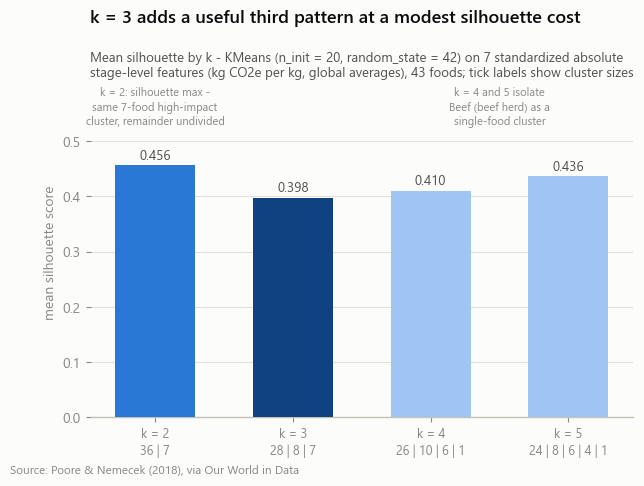

In [4]:
CHOSEN_K = 3
sil = {k: silhouette_score(X, fits[k].labels_) for k in K_RANGE}
sizes_txt = {k: ' | '.join(map(str, np.sort(np.bincount(fits[k].labels_))[::-1])) for k in K_RANGE}

fig, ax = plt.subplots(figsize=(7, 4.3))
ks = list(K_RANGE)
colors = [EMPH_BLUE if k == CHOSEN_K else (BLUE if k == 2 else LIGHT_BLUE) for k in ks]
ax.bar(ks, [sil[k] for k in ks], width=0.58, color=colors, zorder=3)
for k in ks:
    ax.text(k, sil[k] + 0.012, f'{sil[k]:.3f}', ha='center', fontsize=9.5, color=INK2)

ax.text(2, 0.60, 'k = 2: silhouette max -\nsame 7-food high-impact\ncluster, remainder undivided',
        ha='center', va='top', fontsize=8, color=MUTED, linespacing=1.3)
ax.text(4.5, 0.60, 'k = 4 and 5 isolate\nBeef (beef herd) as a\nsingle-food cluster',
        ha='center', va='top', fontsize=8, color=MUTED, linespacing=1.3)

ax.set_xticks(ks)
ax.set_xticklabels([f'k = {k}\n{sizes_txt[k]}' for k in ks], fontsize=9, linespacing=1.4)
ax.set_ylim(0, 0.60)
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.set_ylabel('mean silhouette score')
style_ax(ax, 'y', ('bottom',))
title_block(ax, 'k = 3 adds a useful third pattern at a modest silhouette cost',
            'Mean silhouette by k - KMeans (n_init = 20, random_state = 42) on 7 standardized absolute\n'
            'stage-level features (kg CO2e per kg, global averages), 43 foods; tick labels show cluster sizes',
            pad=46)
source_note(fig)
save_fig(fig, 'fig_appendix_slide06_silhouette.png')
plt.show()


**Choosing k (documented for the slide-12 appendix).** **k = 2 has the highest silhouette
(0.456)**: the 7-food high-impact cluster versus the other 36. **k = 3 (0.398) was selected
for explanatory interpretability**: it preserves the seven-food high-impact cluster
*unchanged* and divides the remaining 36 foods into two interpretable groups (lower-emission
mixed foods; oil, sugar & coffee supply chains). k = 4 (0.410) and k = 5 (0.436) score above
k = 3, but both do so by isolating **Beef (beef herd) as a single-food cluster** (sizes
26 | 10 | 6 | 1 and 24 | 8 | 6 | 4 | 1) - one extreme row (Farm 39.4, Land Use Change 16.3
kg CO2e per kg), not a new food family. We keep k = 3 and report every silhouette (0.456
highest, 0.398 selected) in the appendix table.


In [5]:
km = fits[CHOSEN_K]
df['cluster_id'] = km.labels_
cid = df.set_index('Food product')['cluster_id']

# Name clusters by their feature signatures, via anchor foods (robust to arbitrary
# k-means label order): high farm/feed magnitudes; lower-emission remainder; oils/sugar/coffee.
hi_id = int(cid['Beef (beef herd)'])
oils_id = int(cid['Palm Oil'])
mixed_id = ({0, 1, 2} - {hi_id, oils_id}).pop()
CLUSTER_NAME = {hi_id: 'High farm/feed emissions',
                mixed_id: 'Lower-emission mixed foods',
                oils_id: 'Oil, sugar & coffee supply chains'}
CLUSTER_COLOR = {hi_id: BLUE, mixed_id: GREEN, oils_id: MAGENTA}
CLUSTER_ORDER = [hi_id, mixed_id, oils_id]
df['Cluster'] = df['cluster_id'].map(CLUSTER_NAME)

print('Cluster sizes:', df['Cluster'].value_counts().to_dict(), '\n')
crosstab = pd.crosstab(df['Cluster'], df['Category'])
print(crosstab, '\n')
for i in (hi_id, oils_id):
    members = sorted(df.loc[df['cluster_id'] == i, 'Food product'])
    print(f'{CLUSTER_NAME[i]} (n={len(members)}): {members}')
print('\nAnimal-based foods NOT in the high farm/feed cluster:',
      sorted(df.loc[(df['Category'] == 'Animal-based') & (df['cluster_id'] != hi_id),
                    'Food product']))
print('\nMean land-to-retail total by cluster (kg CO2e/kg):')
print(df.groupby('Cluster')[TOTAL].agg(['mean', 'median']).round(2))


Cluster sizes: {'Lower-emission mixed foods': 28, 'Oil, sugar & coffee supply chains': 8, 'High farm/feed emissions': 7} 

Category                           Animal-based  Plant-based
Cluster                                                     
High farm/feed emissions                      7            0
Lower-emission mixed foods                    3           25
Oil, sugar & coffee supply chains             0            8 

High farm/feed emissions (n=7): ['Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Lamb & Mutton', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)']
Oil, sugar & coffee supply chains (n=8): ['Beet Sugar', 'Cane Sugar', 'Coffee', 'Olive Oil', 'Palm Oil', 'Rapeseed Oil', 'Soybean Oil', 'Sunflower Oil']

Animal-based foods NOT in the high farm/feed cluster: ['Eggs', 'Fish (farmed)', 'Milk']

Mean land-to-retail total by cluster (kg CO2e/kg):
                                    mean  median
Cluster                                         
High farm/feed emissions     

**Validation: a high-impact animal cluster emerges without using the animal/plant labels.**

| Cluster (k = 3) | Animal-based | Plant-based | Mean total (kg CO2e/kg) |
|---|---:|---:|---:|
| High farm/feed emissions | **7** | **0** | 21.6 |
| Lower-emission mixed foods | 3 | 25 | 2.1 |
| Oil, sugar & coffee supply chains | 0 | 8 | 6.0 |

- The **High farm/feed emissions** cluster (both beef herds, Lamb & Mutton, Cheese, Pig Meat,
  Poultry Meat, Shrimps) is 100% animal-based - and the model never saw the labels. The three
  animal foods it excludes are exactly the low-impact animal products: **eggs (4.5), milk
  (2.8) and farmed fish (5.2 kg CO2e/kg) join the lower-emission mixed group**, which is the
  model agreeing with the deck's ranking story.
- The third cluster is a genuine discovery: **Oil, sugar & coffee supply chains** - Beet
  Sugar, Cane Sugar, Coffee, Olive/Palm/Rapeseed/Soybean/Sunflower Oil - crops whose
  emissions concentrate in land-use change, processing and packaging. **Coffee** (16.5 kg
  CO2e/kg, animal-scale) lands here at k = 3. **Dark Chocolate** (18.7 kg) stays in the mixed
  group at k = 3 but joins this family at k = 4 and under Ward linkage (appendix) - the two
  famous plant foods with animal-scale footprints gravitate to this land-use-change-heavy
  family rather than to the high farm/feed cluster.


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_appendix_slide06_clusters_pca.png


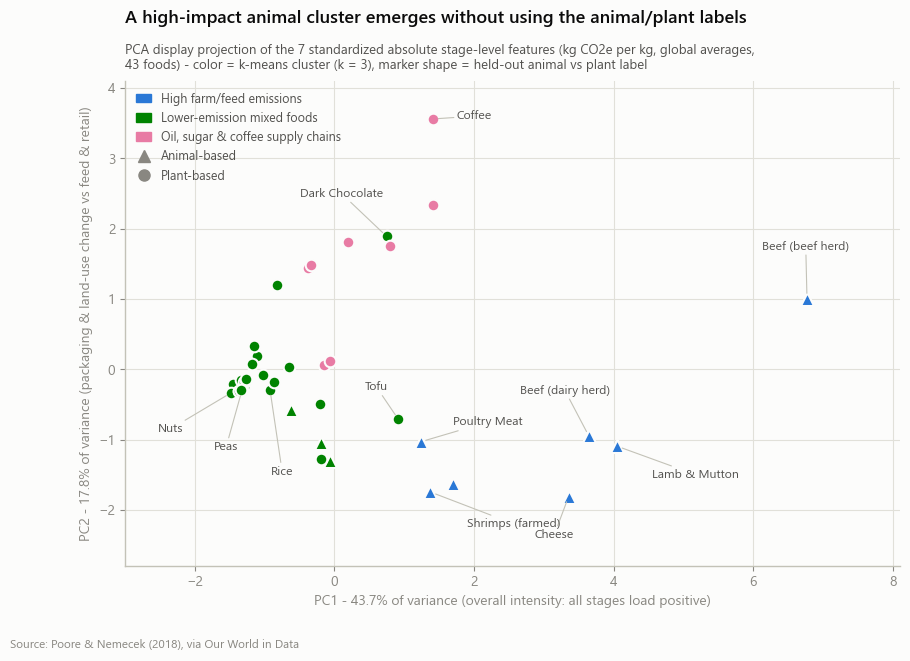

In [6]:
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X)
evr = pca.explained_variance_ratio_ * 100
pts = pd.DataFrame({'x': XY[:, 0], 'y': XY[:, 1], 'food': df['Food product'],
                    'cluster_id': df['cluster_id'],
                    'animal': (df['Category'] == 'Animal-based')})

fig, ax = plt.subplots(figsize=(10, 6.3))
for i in CLUSTER_ORDER:
    for is_animal, mk, sz in [(True, '^', 88), (False, 'o', 70)]:
        s = pts[(pts.cluster_id == i) & (pts.animal == is_animal)]
        if len(s):
            ax.scatter(s.x, s.y, s=sz, marker=mk, color=CLUSTER_COLOR[i],
                       edgecolor=SURFACE, linewidth=1.5, zorder=3)

ANNOTS = {  # food: (text x, text y, ha)
    'Beef (beef herd)':  (6.75, 1.75, 'center'),
    'Beef (dairy herd)': (3.30, -0.30, 'center'),
    'Lamb & Mutton':     (4.55, -1.50, 'left'),
    'Cheese':            (3.15, -2.35, 'center'),
    'Shrimps (farmed)':  (1.90, -2.20, 'left'),
    'Poultry Meat':      (1.70, -0.75, 'left'),
    'Tofu':              (0.60, -0.25, 'center'),
    'Dark Chocolate':    (0.10, 2.50, 'center'),
    'Coffee':            (1.75, 3.60, 'left'),
    'Rice':              (-0.75, -1.45, 'center'),
    'Peas':              (-1.55, -1.10, 'center'),
    'Nuts':              (-2.35, -0.85, 'center'),
}
for food, (tx, ty, ha) in ANNOTS.items():
    r = pts.loc[pts.food == food].iloc[0]
    ax.annotate(food, xy=(r.x, r.y), xytext=(tx, ty), ha=ha, va='center',
                fontsize=8.8, color=INK2,
                arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=4))

handles = [Patch(color=CLUSTER_COLOR[i], label=CLUSTER_NAME[i]) for i in CLUSTER_ORDER]
handles += [Line2D([], [], ls='', marker='^', markersize=8, color=MUTED, label='Animal-based'),
            Line2D([], [], ls='', marker='o', markersize=8, color=MUTED, label='Plant-based')]
ax.legend(handles=handles, loc='upper left', fontsize=9, labelcolor=INK2, handlelength=1.2)

ax.set_xlim(-3.0, 8.1)
ax.set_ylim(-2.8, 4.1)
ax.set_xlabel(f'PC1 - {evr[0]:.1f}% of variance (overall intensity: all stages load positive)')
ax.set_ylabel(f'PC2 - {evr[1]:.1f}% of variance (packaging & land-use change vs feed & retail)')
style_ax(ax, 'both', ('bottom', 'left'))
title_block(ax, 'A high-impact animal cluster emerges without using the animal/plant labels',
            'PCA display projection of the 7 standardized absolute stage-level features '
            '(kg CO2e per kg, global averages,\n43 foods) - color = k-means cluster (k = 3), '
            'marker shape = held-out animal vs plant label', pad=42)
source_note(fig)
save_fig(fig, 'fig_appendix_slide06_clusters_pca.png')
plt.show()


**Reading the map** (axis interpretations follow the computed loadings table in the
appendix). PC1 (43.7% of variance) has every stage loading positive - led by Farm (0.50),
Processing (0.49) and Feed (0.41) - so it reads as *overall supply-chain intensity*:
Beef (beef herd) sits alone at the far right, roughly twice as far out as anything else,
which is also why k = 4 and k = 5 isolate it as a single-food cluster. PC2 (17.8%; 61.5%
of variance shown together) contrasts Packaging (+0.68) and Land Use Change (+0.30) against
Retail (-0.46) and Feed (-0.44): the packaging/land-use-heavy oil, sugar and coffee chains
plot toward the top, the feed-and-retail-heavy animal products toward the bottom. Note the
triangles (animal) inside the green mixed cluster - eggs, milk, farmed fish - and the two
circles drifting upward - Dark Chocolate and Coffee, plant foods with animal-scale totals.


## The insight: WHERE the damage happens

Clustering told us *which* foods behave alike; the absolute stage-level contributions tell
us *why* - and they undercut the most popular intuition about food emissions ("eat local").
Below: the **eight highest-impact foods** by land-to-retail total, with the seven stages
aggregated into four honest groups for legibility (the grouping is stated on the figure):
**Farm + land-use change**, **Feed**, **Processing, packaging & retail**, and **Transport**.
None of these eight foods has a negative land-use-change value, so the stacked bars sum
exactly to each food's land-to-retail total. **Nuts is excluded from this main chart**: it
sits nowhere near the top eight, and its negative land-use-change credit (net carbon
sequestration, -2.05 kg CO2e/kg) requires disproportionate explanation - the appendix
composition check handles it explicitly.


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide06_stage_contributions.png


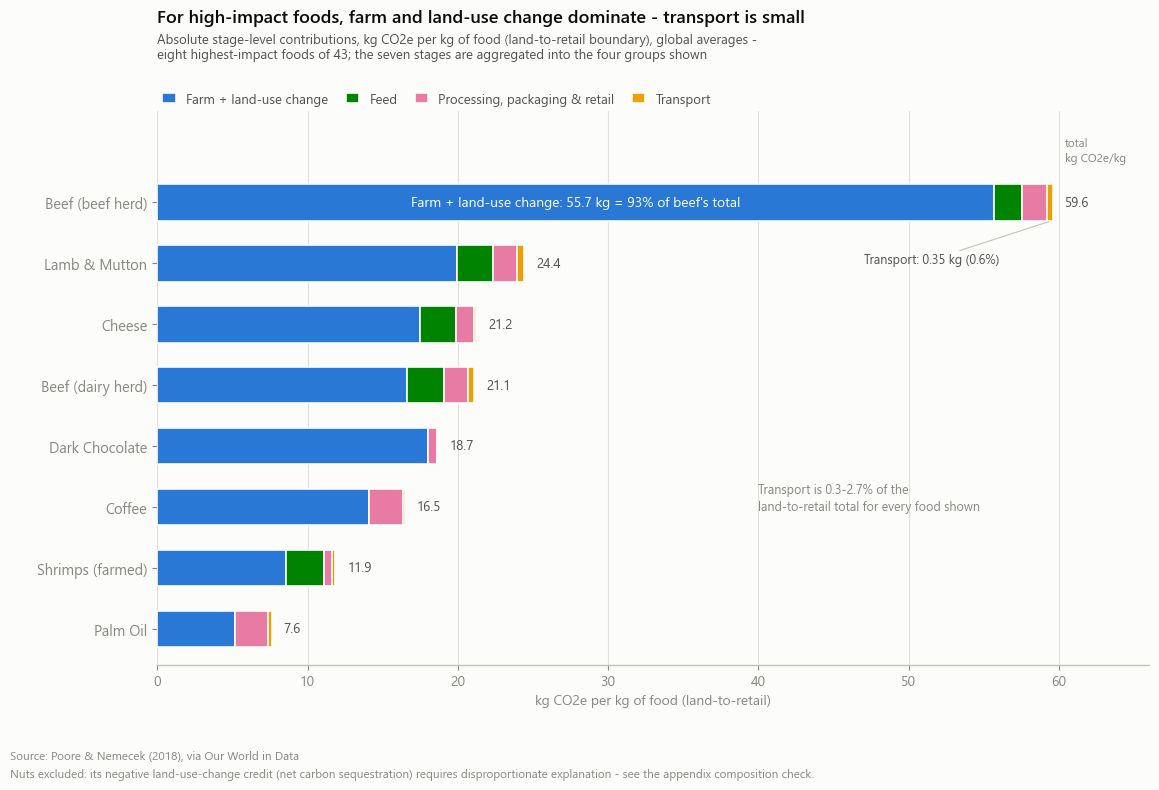

In [7]:
TOP_N = 8
# Nuts excluded by design: its negative land-use-change credit (net sequestration) would
# require disproportionate explanation on the main slide (it is far below the top 8 anyway).
top = (df[df['Food product'] != 'Nuts']
       .sort_values(TOTAL, ascending=False).head(TOP_N).set_index('Food product'))
assert (top['Land Use Change'] >= 0).all()  # honest stacking: no negative segments here

GROUPS = {
    'Farm + land-use change': top['Farm'] + top['Land Use Change'],
    'Feed': top['Feed'],
    'Processing, packaging & retail': top[['Processing', 'Packaging', 'Retail']].sum(axis=1),
    'Transport': top['Transport'],
}
GROUP_COLOR = dict(zip(GROUPS, [BLUE, GREEN, MAGENTA, YELLOW]))
stack_sum = sum(v.to_numpy() for v in GROUPS.values())
assert np.allclose(stack_sum, top[TOTAL].to_numpy(), atol=0.02)

fig, ax = plt.subplots(figsize=(12.8, 7.2))
y = np.arange(len(top))
left = np.zeros(len(top))
for name, vals in GROUPS.items():
    v = vals.to_numpy()
    ax.barh(y, v, left=left, height=0.6, color=GROUP_COLOR[name],
            edgecolor=SURFACE, linewidth=1.2, zorder=3, label=name)
    left += v

ax.set_yticks(y)
ax.set_yticklabels(top.index, fontsize=10.5)
ax.invert_yaxis()
ax.set_ylim(7.6, -1.5)

# Selective direct labels: the beef story
b_fl = GROUPS['Farm + land-use change'].iloc[0]
b_tot = top[TOTAL].iloc[0]
b_tr = top['Transport'].iloc[0]
ax.text(b_fl / 2, 0, f"Farm + land-use change: {b_fl:.1f} kg = {b_fl / b_tot * 100:.0f}% of beef's total",
        ha='center', va='center', fontsize=10, color=ink_on(BLUE), zorder=4)
ax.annotate(f"Transport: {b_tr:.2f} kg ({b_tr / b_tot * 100:.1f}%)",
            xy=(b_tot - b_tr / 2, 0.31), xytext=(51.5, 1.0), ha='center', fontsize=9,
            color=INK2, arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=1))

tshare = top['Transport'] / top[TOTAL] * 100
ax.text(40, 4.6, f'Transport is {tshare.min():.1f}-{tshare.max():.1f}% of the\n'
                 'land-to-retail total for every food shown',
        ha='left', va='top', fontsize=9, color=MUTED, linespacing=1.4)

# Right column: land-to-retail totals
for yi, food in enumerate(top.index):
    ax.text(top.loc[food, TOTAL] + 0.8, yi, f'{top.loc[food, TOTAL]:.1f}',
            va='center', ha='left', fontsize=9.5, color=INK2)
ax.text(60.4, -0.85, 'total\nkg CO2e/kg', ha='left', va='center', fontsize=8.5,
        color=MUTED, linespacing=1.3)

ax.set_xlim(0, 66)
ax.set_xlabel('kg CO2e per kg of food (land-to-retail)')
style_ax(ax, 'x', ('bottom',))
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=4, fontsize=9.5,
          handlelength=1.0, columnspacing=1.3, labelcolor=INK2, borderaxespad=0)
title_block(ax, 'For high-impact foods, farm and land-use change dominate - transport is small',
            'Absolute stage-level contributions, kg CO2e per kg of food (land-to-retail '
            'boundary), global averages -\neight highest-impact foods of 43; the seven stages '
            'are aggregated into the four groups shown', pad=64, sub_y=1.09)
source_note(fig)
fig.text(0.01, -0.045, 'Nuts excluded: its negative land-use-change credit (net carbon '
         'sequestration) requires disproportionate explanation - see the appendix composition check.',
         fontsize=8.5, color=MUTED, ha='left')
save_fig(fig, 'fig_slide06_stage_contributions.png')
plt.show()


In [8]:
# Numbers for the deck (computed, not typed)
beef_r = ix.loc['Beef (beef herd)']
print(f"Beef transport share: {beef_r['Transport']:.3f} / {beef_r[TOTAL]:.2f} = "
      f"{beef_r['Transport'] / beef_r[TOTAL] * 100:.2f}%")
print(f"Beef farm + land-use change share: "
      f"{(beef_r['Farm'] + beef_r['Land Use Change']) / beef_r[TOTAL] * 100:.1f}%")
print(f"Beef vs peas, land-to-retail: {beef_r[TOTAL] / ix.loc['Peas', TOTAL]:.1f}x")
GA = 'Total Global Average GHG Emissions per kg'
print(f"Companion series - source file's '{GA}' column: beef {beef_r[GA]:.1f} vs peas "
      f"{ix.loc['Peas', GA]:.1f} -> {beef_r[GA] / ix.loc['Peas', GA]:.0f}x "
      f"(the repository does not document the exact scope difference vs the stage columns)")
tshare = (df['Transport'] / df[TOTAL] * 100)
print(f"Max transport share among foods with totals > 5 kg CO2e/kg: "
      f"{tshare[df[TOTAL] > 5].max():.1f}% ({df.loc[tshare[df[TOTAL] > 5].idxmax(), 'Food product']})")
big_t = df.loc[tshare > 25, ['Food product', TOTAL]].assign(share=tshare[tshare > 25].round(0))
print('\nFoods where transport exceeds 25% of the footprint (all low-impact):')
print(big_t.sort_values('share', ascending=False).to_string(index=False))


Beef transport share: 0.346 / 59.57 = 0.58%
Beef farm + land-use change share: 93.4%
Beef vs peas, land-to-retail: 66.5x
Companion series - source file's 'Total Global Average GHG Emissions per kg' column: beef 99.5 vs peas 1.0 -> 102x (the repository does not document the exact scope difference vs the stage columns)
Max transport share among foods with totals > 5 kg CO2e/kg: 8.1% (Olive Oil)

Foods where transport exceeds 25% of the footprint (all low-impact):
    Food product  Total from Land to Retail  share
         Bananas                      0.678   43.0
      Beet Sugar                      1.536   41.0
Other Vegetables                      0.455   36.0
 Root Vegetables                      0.365   31.0
    Citrus Fruit                      0.317   30.0
      Cane Sugar                      2.672   29.0
          Apples                      0.357   27.0
        Potatoes                      0.370   25.0


**Takeaway - the slide-6 punchline.** For Beef (beef herd), transport is **0.346 of 59.57 kg
CO2e/kg = 0.6%** of the footprint, and farm + land-use change together are **93.4%**
(66% on-farm - mostly cattle methane - plus 27% land-use change). The pattern holds across
the high farm/feed cluster: transport never exceeds ~5% of any animal product's footprint,
and among *all* foods above 5 kg CO2e/kg the largest transport share is 8.1% (Olive Oil).
Transport only becomes a big *share* (25-43%) for foods whose totals are already tiny -
Bananas (43% of 0.68 kg), Beet Sugar (41% of 1.5 kg), Apples (27% of 0.36 kg).

**"Eat local" therefore optimizes one of the smallest slices of the highest-impact foods,
while switching *what* you eat moves the whole bar: beef to peas is 59.6 vs 0.9 kg CO2e/kg -
a 66x difference on the land-to-retail basis.** (On the source file's companion "Total Global
Average GHG Emissions per kg" column the same comparison is about 102x; the repository does
not document the exact scope difference between the two measures, so we quote that number
only as a companion figure.) Rice and Tofu - the deck's plant swaps - sit at 3.8 and 2.9 kg,
an order of magnitude below the ruminants, and Nuts even ends up *net-negative* on land use
because orchards sequester carbon.


## Appendix (slide 12): sensitivity and robustness checks

**Check 1 - magnitude-blind composition clustering (descriptive).** Re-run the pipeline on
stage *composition* instead of absolute values. Shares are computed against the **gross
positive total** (sum of positive stages) - never against the net land-to-retail total,
which is near zero for Nuts (0.28 kg) and would inflate its shares beyond meaning. Because
the positive shares sum to 1 by construction, one redundant column (Retail) is dropped
before clustering, and the land-use-change sequestration credit enters as its own bounded
feature (credit / gross total). This deliberately erases *how much* each food emits and
keeps only *where along the chain* it emits; we treat it as a descriptive sensitivity
analysis, not a competing model.

**Check 2 - a different algorithm family.** Ward hierarchical clustering (scipy) on the same
standardized absolute stage features, cut at 3 clusters, compared to the main k-means
partition with the **adjusted Rand index (ARI)**.

**Check 3 - signed-log robustness.** Compress magnitudes with
`signed_log(x) = sign(x) * log1p(|x|)`, re-standardize, re-cluster at k = 3, and compare to
the main partition by ARI.

**Plus:** the computed PCA loadings table behind the display projection on the cluster map.


Nuts on the gross basis: farm share 0.91, LUC credit 0.88 (bounded - no exploding shares)



   silhouette cluster sizes (desc)
k                                 
2       0.280              33 | 10
3       0.267          26 | 10 | 7
4       0.227     19 | 13 | 10 | 1
5       0.266  17 | 15 | 7 | 3 | 1 

Category                      Animal-based  Plant-based
composition cluster                                    
Downstream-heavy shares                  0           10
Farm-dominated shares                    7           19
Land-use & feed-heavy shares             3            4 

Mean feature values by composition cluster:
                              Land Use Change   Feed   Farm  Processing  \
cluster                                                                   
Downstream-heavy shares                 0.119  0.000  0.336       0.149   
Farm-dominated shares                   0.077  0.031  0.648       0.024   
Land-use & feed-heavy shares            0.446  0.169  0.212       0.027   

                              Transport  Packaging  LUC credit  
cluster             

saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_appendix_slide06_composition_check.png


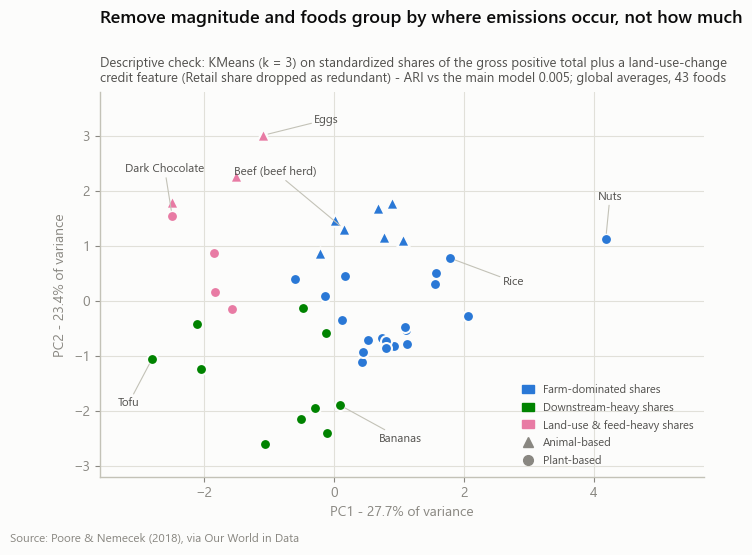

In [9]:
# Check 1 - corrected composition basis: shares of the GROSS positive total, never the net
# land-to-retail total (which is near zero for Nuts and would inflate its shares).
positive_stages = df[STAGES].clip(lower=0)
gross_total = positive_stages.sum(axis=1)
positive_shares = positive_stages.div(gross_total, axis=0)
luc_credit = (-df['Land Use Change'].clip(upper=0)).div(gross_total)

# Positive shares sum to 1 by construction -> drop one redundant column (Retail) before
# clustering; the land-use-change sequestration credit enters as its own bounded feature.
comp_feat = positive_shares.drop(columns=['Retail']).copy()
comp_feat['LUC credit'] = luc_credit
nuts = df['Food product'] == 'Nuts'
print(f"Nuts on the gross basis: farm share {positive_shares.loc[nuts, 'Farm'].iloc[0]:.2f}, "
      f"LUC credit {luc_credit.loc[nuts].iloc[0]:.2f} (bounded - no exploding shares)\n")

Xc = StandardScaler().fit_transform(comp_feat.to_numpy())
rows_c = []
for k in K_RANGE:
    km_c = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xc)
    rows_c.append({'k': k,
                   'silhouette': round(silhouette_score(Xc, km_c.labels_), 3),
                   'cluster sizes (desc)': ' | '.join(
                       map(str, np.sort(np.bincount(km_c.labels_))[::-1]))})
sel_c = pd.DataFrame(rows_c).set_index('k')
print(sel_c, '\n')

km_c3 = KMeans(n_clusters=3, n_init=20, random_state=42).fit(Xc)
lab_c = km_c3.labels_
cid_c = pd.Series(lab_c, index=df['Food product'])
farm_id = int(cid_c['Beef (beef herd)'])
down_id = int(cid_c['Bananas'])
lucfeed_id = int(cid_c['Dark Chocolate'])
NAME_C = {farm_id: 'Farm-dominated shares', down_id: 'Downstream-heavy shares',
          lucfeed_id: 'Land-use & feed-heavy shares'}
COLOR_C = {farm_id: BLUE, down_id: GREEN, lucfeed_id: MAGENTA}
print(pd.crosstab(pd.Series(lab_c).map(NAME_C).rename('composition cluster'), df['Category']), '\n')
print('Mean feature values by composition cluster:')
mf = comp_feat.copy()
mf['cluster'] = pd.Series(lab_c).map(NAME_C)
print(mf.groupby('cluster').mean().round(3), '\n')

ari_composition = adjusted_rand_score(df['cluster_id'], lab_c)
print(f'ARI, main k = 3 partition vs composition k = 3 partition: {ari_composition:.3f}')
print('Farm-dominated shares contains, e.g.:',
      sorted(set(df.loc[lab_c == farm_id, 'Food product'])
             & {'Beef (beef herd)', 'Rice', 'Coffee', 'Nuts', 'Peas', 'Milk'}))

pca_c = PCA(n_components=2, random_state=42)
XYc = pca_c.fit_transform(Xc)
evr_c = pca_c.explained_variance_ratio_ * 100
pts_c = pd.DataFrame({'x': XYc[:, 0], 'y': XYc[:, 1], 'food': df['Food product'],
                      'c': lab_c, 'animal': (df['Category'] == 'Animal-based')})

fig, ax = plt.subplots(figsize=(7.8, 5.0))
for i in (farm_id, down_id, lucfeed_id):
    for is_animal, mk, sz in [(True, '^', 80), (False, 'o', 62)]:
        s = pts_c[(pts_c.c == i) & (pts_c.animal == is_animal)]
        if len(s):
            ax.scatter(s.x, s.y, s=sz, marker=mk, color=COLOR_C[i],
                       edgecolor=SURFACE, linewidth=1.5, zorder=3)
ANNOTS_C = {'Beef (beef herd)': (-0.90, 2.35, 'center'), 'Rice': (2.60, 0.35, 'left'),
            'Nuts': (4.25, 1.90, 'center'), 'Bananas': (0.70, -2.50, 'left'),
            'Dark Chocolate': (-2.60, 2.40, 'center'), 'Eggs': (-0.30, 3.30, 'left'),
            'Tofu': (-3.15, -1.85, 'center')}
for food, (tx, ty, ha) in ANNOTS_C.items():
    r = pts_c.loc[pts_c.food == food].iloc[0]
    ax.annotate(food, xy=(r.x, r.y), xytext=(tx, ty), ha=ha, va='center',
                fontsize=8.5, color=INK2,
                arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=4))
handles = [Patch(color=COLOR_C[i], label=NAME_C[i]) for i in (farm_id, down_id, lucfeed_id)]
handles += [Line2D([], [], ls='', marker='^', markersize=7, color=MUTED, label='Animal-based'),
            Line2D([], [], ls='', marker='o', markersize=7, color=MUTED, label='Plant-based')]
ax.legend(handles=handles, loc='lower right', fontsize=8.2, labelcolor=INK2, handlelength=1.1)
ax.set_xlim(-3.6, 5.7)
ax.set_ylim(-3.2, 3.8)
ax.set_xlabel(f'PC1 - {evr_c[0]:.1f}% of variance')
ax.set_ylabel(f'PC2 - {evr_c[1]:.1f}% of variance')
style_ax(ax, 'both', ('bottom', 'left'))
title_block(ax, 'Remove magnitude and foods group by where emissions occur, not how much',
            f'Descriptive check: KMeans (k = 3) on standardized shares of the gross positive '
            f'total plus a land-use-change\ncredit feature (Retail share dropped as redundant) '
            f'- ARI vs the main model {ari_composition:.3f}; global averages, 43 foods', pad=50)
source_note(fig)
save_fig(fig, 'fig_appendix_slide06_composition_check.png')
plt.show()


**Check 1 result: remove magnitude and the animal/plant separation dissolves - as it
should.** On the gross-share basis Nuts is no longer an artifact: its farm share is 0.91 and
its sequestration credit 0.88, both bounded. The sweep gives k = 2 = 0.280 (33 | 10) and
k = 3 = 0.267 (26 | 10 | 7); at k >= 4 a single-food cluster appears (Nuts - its
land-use-change credit is unique in the data, and we describe it as exactly that: a
single-food cluster). At k = 3 the groups describe *where* emissions occur:

- **Farm-dominated shares** (26 foods, mean farm share 0.65): both beef herds, Cheese,
  Lamb & Mutton, Shrimps, Milk and farmed Fish together with Rice, Peas, Apples, Coffee,
  Nuts and most oils - beef and rice have similarly farm-heavy stage mixes; beef's is just
  an order of magnitude taller.
- **Downstream-heavy shares** (10 foods): Bananas, Barley, Beet Sugar, Tofu, Wine and other
  foods - including Palm Oil - whose processing, transport and packaging together carry
  most of the stage mix.
- **Land-use & feed-heavy shares** (7 foods): Dark Chocolate, Cane Sugar, Cassava and
  Soybean Oil (large land-use-change shares) plus Eggs, Pig Meat and Poultry Meat (large
  feed shares).

The **ARI against the main model is 0.005 - essentially unrelated partitions**. Animal and
plant no longer separate (the farm-dominated cluster mixes 7 animal with 19 plant foods),
confirming that the main model's headline separation is carried by the **magnitude** of
farm-stage emissions, not by the shape of the stage mix. That is exactly why the
magnitude-aware model is the main model and this check is descriptive, living in the
appendix.


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_appendix_slide06_dendrogram.png


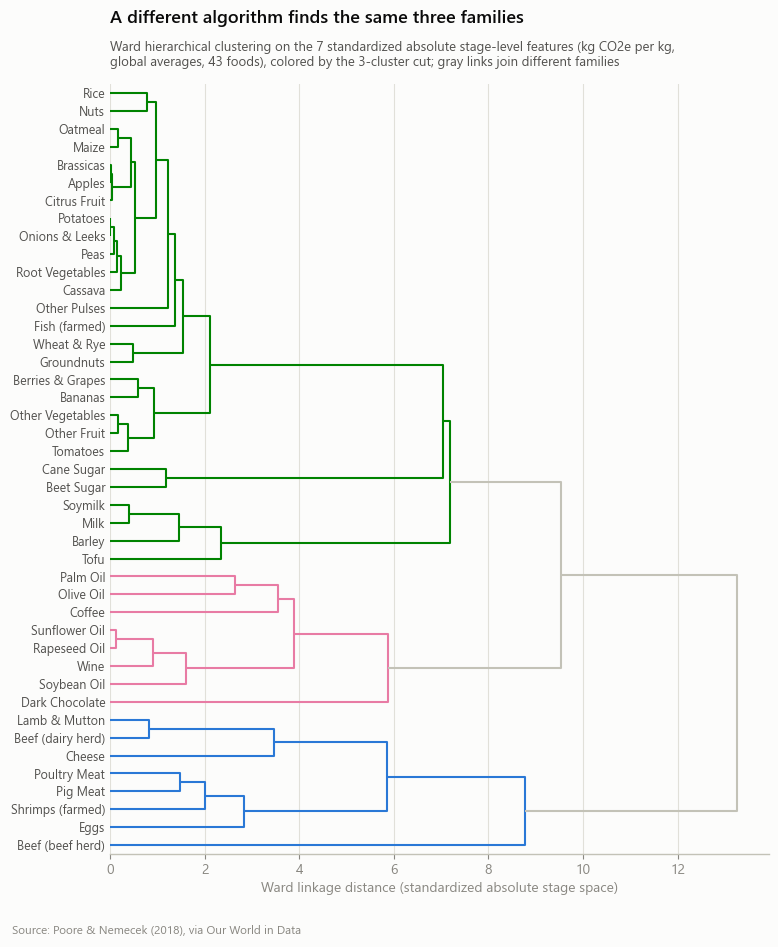

Ward 3-cluster cut sizes: {1: np.int64(8), 2: np.int64(8), 3: np.int64(27)}
  cluster 1 (high-impact-like): ['Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Eggs', 'Lamb & Mutton', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)']
  cluster 2 (oils & coffee-like): ['Coffee', 'Dark Chocolate', 'Olive Oil', 'Palm Oil', 'Rapeseed Oil', 'Soybean Oil', 'Sunflower Oil', 'Wine']
  cluster 3 (mixed-like): ['Apples', 'Bananas', 'Barley', 'Beet Sugar', 'Berries & Grapes', 'Brassicas', 'Cane Sugar', 'Cassava', 'Citrus Fruit', 'Fish (farmed)', 'Groundnuts', 'Maize', 'Milk', 'Nuts', 'Oatmeal', 'Onions & Leeks', 'Other Fruit', 'Other Pulses', 'Other Vegetables', 'Peas', 'Potatoes', 'Rice', 'Root Vegetables', 'Soymilk', 'Tofu', 'Tomatoes', 'Wheat & Rye']

ARI, main k = 3 k-means partition vs Ward 3-cluster cut: 0.648 (meaningful but not perfect agreement)


In [10]:
Z = linkage(X, method='ward')
cut3 = fcluster(Z, t=3, criterion='maxclust')
ari_ward = adjusted_rand_score(df['cluster_id'], cut3)

pos = {f: i for i, f in enumerate(df['Food product'])}
ward_color = {int(cut3[pos['Beef (beef herd)']]): BLUE, int(cut3[pos['Palm Oil']]): MAGENTA}
for c in set(cut3):
    ward_color.setdefault(int(c), GREEN)

n = len(df)
cluster_of = {i: int(cut3[i]) for i in range(n)}
link_cols = {}
for i, (a, b_, *_rest) in enumerate(Z):
    ca, cb = cluster_of.get(int(a)), cluster_of.get(int(b_))
    same = ca if (ca == cb and ca is not None) else None
    cluster_of[n + i] = same
    link_cols[n + i] = ward_color[same] if same is not None else BASE

fig, ax = plt.subplots(figsize=(8.5, 10))
dendrogram(Z, labels=df['Food product'].tolist(), orientation='right',
           link_color_func=lambda nid: link_cols.get(nid, BASE), ax=ax, leaf_font_size=9)
for lbl in ax.get_ymajorticklabels():
    lbl.set_color(INK2)
ax.tick_params(axis='y', length=0)
ax.set_xlabel('Ward linkage distance (standardized absolute stage space)')
style_ax(ax, 'x', ('bottom',))
title_block(ax, 'A different algorithm finds the same three families',
            'Ward hierarchical clustering on the 7 standardized absolute stage-level features '
            '(kg CO2e per kg,\nglobal averages, 43 foods), colored by the 3-cluster cut; '
            'gray links join different families', pad=44)
source_note(fig, y=0.03)
save_fig(fig, 'fig_appendix_slide06_dendrogram.png')
plt.show()

print('Ward 3-cluster cut sizes:', dict(pd.Series(cut3).value_counts().sort_index()))
WARD_LIKE = {BLUE: 'high-impact-like', MAGENTA: 'oils & coffee-like', GREEN: 'mixed-like'}
for c in sorted(set(cut3)):
    print(f'  cluster {c} ({WARD_LIKE[ward_color[int(c)]]}):',
          sorted(df.loc[cut3 == c, 'Food product'])[:30])
print(f'\nARI, main k = 3 k-means partition vs Ward 3-cluster cut: {ari_ward:.3f} '
      '(meaningful but not perfect agreement)')


**Check 2 result: Ward agrees - meaningfully, not perfectly.** Cutting the Ward tree at 3
clusters reproduces the same three families with only edge moves: **Eggs joins the
high-impact-like cluster** (8 foods, still all-animal), **Dark Chocolate and Wine join the
oils & coffee family** (8 foods), and the two sugars fall back into the mixed group
(27 foods). The **adjusted Rand index between the main k = 3 k-means partition and the Ward
3-cluster cut is 0.65 - meaningful but not perfect agreement**: the three families are
stable and the entire difference is these borderline foods. The deepest split in the tree is
the high-impact cluster vs everything else - the same structure the k = 2 k-means solution
finds.

### Model-selection metrics (feeds the slide-12 appendix)

| k | Silhouette - absolute stage values (main) | Cluster sizes | Silhouette - composition check | Cluster sizes |
|---:|---:|---|---:|---|
| 2 | **0.456** (highest) | 36 \| 7 | 0.280 | 33 \| 10 |
| 3 | 0.398 **(selected)** | 28 \| 8 \| 7 | 0.267 | 26 \| 10 \| 7 |
| 4 | 0.410 | 26 \| 10 \| 6 \| 1 | 0.227 | 19 \| 13 \| 10 \| 1 |
| 5 | 0.436 | 24 \| 8 \| 6 \| 4 \| 1 | 0.266 | 17 \| 15 \| 7 \| 3 \| 1 |

Chosen model: **k = 3 on standardized absolute stage values** (High farm/feed emissions 7,
Lower-emission mixed foods 28, Oil, sugar & coffee supply chains 8), selected for
explanatory interpretability at a modest silhouette cost. At k >= 4 the main pipeline
isolates Beef (beef herd) as a single-food cluster; the composition check does the same
with Nuts.


In [11]:
# Check 3 - signed-log robustness: compress magnitudes, re-standardize, re-cluster at k = 3.
vals = df[STAGES].to_numpy()
signed_log = np.sign(vals) * np.log1p(np.abs(vals))
X_log = StandardScaler().fit_transform(signed_log)
km_log = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X_log)
ari_signed_log = adjusted_rand_score(df['cluster_id'], km_log.labels_)

print('Signed-log k = 3 cluster sizes:', sorted(np.bincount(km_log.labels_).tolist())[::-1])
print(pd.crosstab(df['Cluster'].rename('main cluster'),
                  pd.Series(km_log.labels_, name='signed-log cluster')), '\n')
hi_main = set(df.loc[df['cluster_id'] == hi_id, 'Food product'])
hi_log_id = int(pd.Series(km_log.labels_, index=df['Food product'])['Beef (beef herd)'])
hi_log = set(df.loc[km_log.labels_ == hi_log_id, 'Food product'])
print('High farm/feed cluster identical under signed-log:', hi_main == hi_log)
print(f'\nARI, main k = 3 partition vs signed-log k = 3 partition: {ari_signed_log:.3f} '
      '(strong but not perfect agreement)')


Signed-log k = 3 cluster sizes: [29, 7, 7]
signed-log cluster                  0  1  2
main cluster                               
High farm/feed emissions            0  7  0
Lower-emission mixed foods         27  0  1
Oil, sugar & coffee supply chains   2  0  6 

High farm/feed cluster identical under signed-log: True

ARI, main k = 3 partition vs signed-log k = 3 partition: 0.781 (strong but not perfect agreement)


**Check 3 result: the headline structure survives magnitude compression.** Under the
signed-log transform the k = 3 partition keeps the **identical seven-food high farm/feed
cluster**, moves the two sugars from the oils group into the mixed group, and moves Dark
Chocolate the other way (joining Coffee and the five oils). The **ARI against the main
model is 0.78 - strong but not perfect agreement**: only borderline members of the oils
group reshuffle, so the deck's story does not hinge on the linear scale of the features.


In [12]:
# PCA loadings for the display projection - computed from the fitted PCA, never hard-coded.
loadings = pd.DataFrame(pca.components_.T, index=STAGES, columns=['PC1', 'PC2']).round(3)
print(f'Explained variance: PC1 {evr[0]:.1f}%, PC2 {evr[1]:.1f}% '
      f'(together {evr[0] + evr[1]:.1f}%)')
loadings


Explained variance: PC1 43.7%, PC2 17.8% (together 61.5%)


,PC1,PC2
Land Use Change,0.363,0.295
Feed,0.409,-0.441
Farm,0.504,0.052
Processing,0.491,0.182
Transport,0.251,0.044
Packaging,0.156,0.684
Retail,0.346,-0.462


**Reading the loadings.** PC1 loads positive on all seven stages (Farm 0.50, Processing
0.49, Feed 0.41, Land Use Change 0.36, Retail 0.35, Transport 0.25, Packaging 0.16) - a
general supply-chain-intensity axis. PC2 contrasts Packaging (+0.68) and Land Use Change
(+0.30) against Retail (-0.46) and Feed (-0.44), separating the packaging/land-use-heavy
oil, sugar and coffee chains from the feed-and-retail-heavy animal products. These computed
numbers are the basis for the axis annotations on the cluster map above.


## Limitations

- **n = 43 global averages.** Each row is one global mean; Poore & Nemecek's underlying data
  show enormous producer-level spread (the 10th-90th percentile range for beef spans tens of
  kg), so clusters describe *typical* products, not every farm. With 43 observations, single
  foods can visibly move results.
- **Outlier sensitivity.** Beef (beef herd) is extreme enough to become a single-food
  cluster at k >= 4 in the main pipeline, and in the composition check Nuts (the only food
  with a large land-use-change sequestration credit) becomes a single-food cluster at
  k >= 4. We chose k by silhouette *plus* interpretability and report every score rather
  than hiding any of them.
- **K-means assumptions.** K-means prefers spherical, similarly sized clusters in the scaled
  space and hard-assigns borderline foods (Dark Chocolate flips family between k = 3, k = 4,
  Ward linkage, and the signed-log check). The Ward and signed-log checks mitigate but do
  not eliminate this.
- **Standardization choice.** Silhouette values depend on the feature scaling decision;
  we report scores within each pipeline, not across pipelines.
- **Stage taxonomy.** The 7 stages are already aggregates (e.g. "Farm" bundles methane,
  fertilizer, machinery); transport here is the supply-chain average and excludes rare
  air-freighted produce, a known exception to the "transport is small" rule.
- **Vintage.** The source synthesizes studies up to ~2016 (published 2018); absolute values
  will have shifted, though the orders of magnitude that drive the clusters are stable.


## Sources

- Poore, J., & Nemecek, T. (2018). Reducing food's environmental impacts through producers
  and consumers. *Science*, 360(6392), 987-992. Data as distributed by Our World in Data
  (`data/Food_Product_Emissions.csv`).
- Emissions basis: "Total from Land to Retail" (land-to-retail total) throughout; the file's
  "Total Global Average GHG Emissions per kg" column is quoted only as a companion per-kg
  series - the repository does not document the exact scope difference between the two
  measures.
- Tooling: Python 3.12, pandas 3.0, scikit-learn 1.8 (StandardScaler, KMeans, PCA,
  silhouette_score, adjusted_rand_score), scipy 1.17 (Ward linkage), matplotlib 3.10. All
  stochastic steps use `random_state=42`; k-means uses `n_init=20`.
